In [3]:
import kagglehub
import pandas as pd

# Download dataset
path = kagglehub.dataset_download(
    "shivamb/machine-predictive-maintenance-classification"
)

print(path)

100%|██████████| 137k/137k [00:00<00:00, 41.3MB/s]

Extracting files...
/root/.cache/kagglehub/datasets/shivamb/machine-predictive-maintenance-classification/versions/1


In [4]:
df = pd.read_csv(f"{path}/predictive_maintenance.csv")

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

In [11]:
df.shape
df.info()
df.describe()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Type                     10000 non-null  object 
 1   Air temperature [K]      10000 non-null  float64
 2   Process temperature [K]  10000 non-null  float64
 3   Rotational speed [rpm]   10000 non-null  int64  
 4   Torque [Nm]              10000 non-null  float64
 5   Tool wear [min]          10000 non-null  int64  
 6   Target                   10000 non-null  int64  
 7   Failure Type             10000 non-null  object 
 8   temp_diff                10000 non-null  float64
 9   power                    10000 non-null  float64
dtypes: float64(5), int64(3), object(2)
memory usage: 781.4+ KB


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type,temp_diff,power
0,M,298.1,308.6,1551,42.8,0,0,No Failure,10.5,6951.590560
1,L,298.2,308.7,1408,46.3,3,0,No Failure,10.5,6826.722724
2,L,298.1,308.5,1498,49.4,5,0,No Failure,10.4,7749.387543
3,L,298.2,308.6,1433,39.5,7,0,No Failure,10.4,5927.504659
4,L,298.2,308.7,1408,40.0,9,0,No Failure,10.5,5897.816608


In [12]:

df.count()

,0
Type,10000
Air temperature [K],10000
Process temperature [K],10000
Rotational speed [rpm],10000
Torque [Nm],10000
Tool wear [min],10000
Target,10000
Failure Type,10000
temp_diff,10000
power,10000


In [13]:
print(len(df))

10000


In [17]:
# UDI and Product ID are not useful for modeling
df.drop(columns=["UDI", "Product ID"], inplace=True)

KeyError: "['UDI', 'Product ID'] not found in axis"

In [18]:
# Target: Machine failure (0/1)
target = "Machine failure"

In [19]:
# Temperature difference
df["temp_diff"] = df["Process temperature [K]"] - df["Air temperature [K]"]

# Power approximation
df["power"] = (2 * np.pi * df["Rotational speed [rpm]"] / 60) * df["Torque [Nm]"]

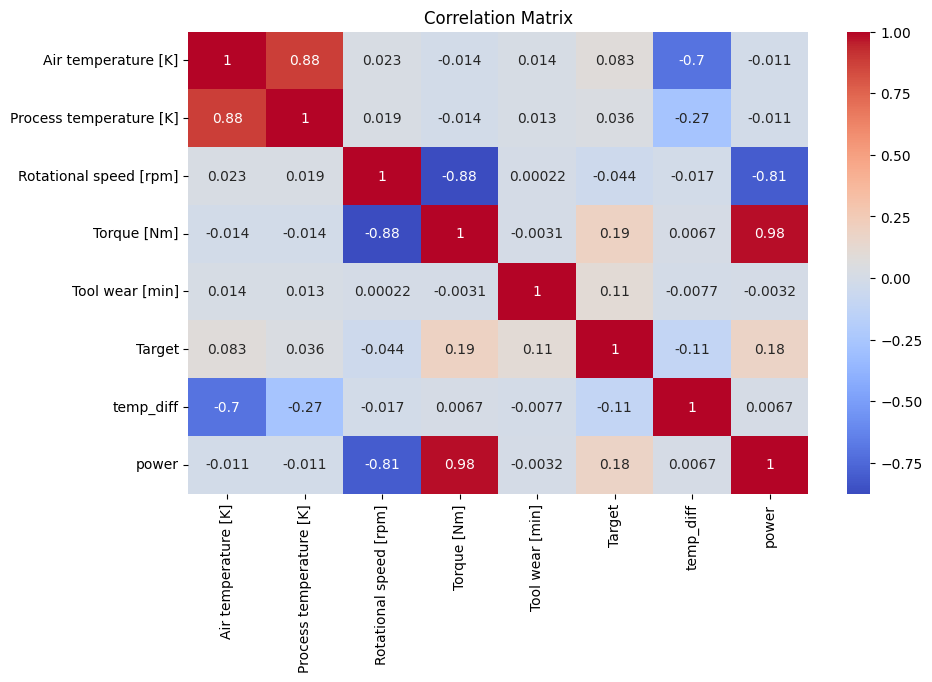

In [20]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [24]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Target',
       'Failure Type', 'temp_diff', 'power'],
      dtype='object')


In [27]:
[c for c in df.columns if "fail" in c.lower()]

['Failure Type']

In [30]:
print(df.columns.tolist())


['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Target', 'Failure Type', 'temp_diff', 'power']


In [31]:

df.columns = df.columns.str.strip()
print(df.columns.tolist())

['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Target', 'Failure Type', 'temp_diff', 'power']


In [32]:
for col in df.columns:
    if "fail" in col.lower():
        print(col)

Failure Type


In [33]:
target_col = [col for col in df.columns if "fail" in col.lower()][0]

X = df.drop(columns=[target_col])
y = df[target_col]

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [36]:
df.columns = df.columns.str.strip()

X = df.drop(columns=[col for col in df.columns if "fail" in col.lower()][0])
y = df[[col for col in df.columns if "fail" in col.lower()][0]]

X = pd.get_dummies(X, drop_first=True)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [39]:
print(hasattr(rf_model, "estimators_"))

False


In [40]:
rf_model = RandomForestClassifier()
# forgot fit OR re-ran cell incorrectly

In [42]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [44]:
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:,1]

In [45]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.997

Classification Report:
                           precision    recall  f1-score   support

Heat Dissipation Failure       1.00      1.00      1.00        22
              No Failure       1.00      1.00      1.00      1930
      Overstrain Failure       0.89      1.00      0.94        16
           Power Failure       1.00      1.00      1.00        19
         Random Failures       0.00      0.00      0.00         4
       Tool Wear Failure       1.00      0.78      0.88         9

                accuracy                           1.00      2000
               macro avg       0.81      0.80      0.80      2000
            weighted avg       1.00      1.00      1.00      2000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


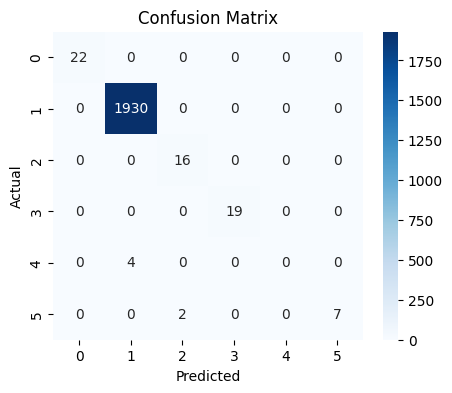

In [46]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [51]:
print(y.value_counts())
print(y.nunique())

Failure Type
No Failure                  9652
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45
Random Failures               18
Name: count, dtype: int64
6


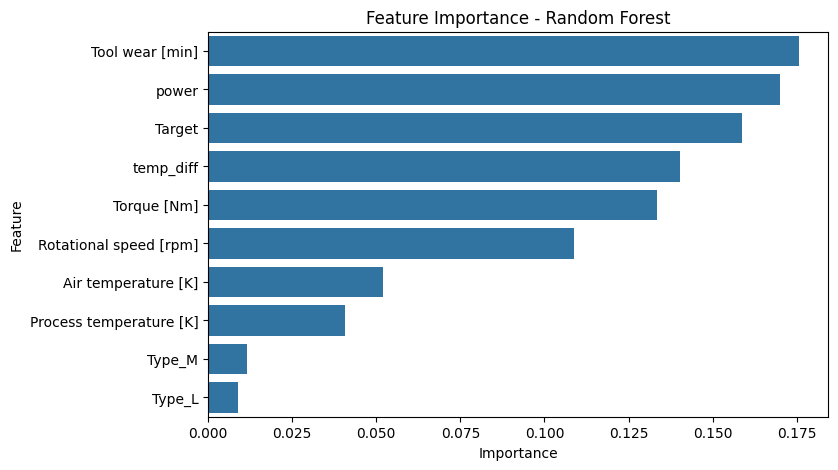

In [48]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(data=feature_importance, x="Importance", y="Feature")
plt.title("Feature Importance - Random Forest")
plt.show()

In [49]:
df_test = X_test.copy()
df_test["failure_probability"] = y_prob

def risk_level(p):
    if p < 0.3:
        return "Low Risk - Normal Operation"
    elif p < 0.7:
        return "Medium Risk - Inspect Soon"
    else:
        return "High Risk - Immediate Maintenance"

df_test["risk_level"] = df_test["failure_probability"].apply(risk_level)

df_test.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,temp_diff,power,Type_L,Type_M,failure_probability,risk_level
3811,302.1,310.7,1608,30.3,81,0,8.6,5102.197797,False,True,1.000,High Risk - Immediate Maintenance
8020,300.9,312.0,1720,27.9,202,0,11.1,5025.291609,False,False,1.000,High Risk - Immediate Maintenance
8217,299.1,310.6,1577,37.1,44,0,11.5,6126.807297,True,False,1.000,High Risk - Immediate Maintenance
6314,301.0,310.4,1793,25.0,142,0,9.4,4694.063023,False,True,1.000,High Risk - Immediate Maintenance
9974,298.6,308.2,1361,68.2,172,1,9.6,9720.108614,True,False,0.005,Low Risk - Normal Operation


In [50]:
df_test["risk_level"].value_counts()

,count
risk_level,
High Risk - Immediate Maintenance,1934
Low Risk - Normal Operation,66
